In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plot

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
data = pd.read_csv("../Datasets/titanic.csv")
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [4]:
print("all rows:",len(data))
print(data.isnull().sum())
print(data.isnull().mean())

all rows: 1309
pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64
pclass       0.000000
survived     0.000000
name         0.000000
sex          0.000000
age          0.200917
sibsp        0.000000
parch        0.000000
ticket       0.000000
fare         0.000764
cabin        0.774637
embarked     0.001528
boat         0.628724
body         0.907563
home.dest    0.430863
dtype: float64


In [5]:
data['cabin_null'] = np.where(data['cabin'].isnull(), 1,0)

In [6]:

data['cabin_null']

0       0
1       0
2       0
3       0
4       0
       ..
1304    1
1305    1
1306    1
1307    1
1308    1
Name: cabin_null, Length: 1309, dtype: int64

In [7]:
data.groupby(['survived'])['cabin_null'].mean()

survived
0    0.873918
1    0.614000
Name: cabin_null, dtype: float64

In [8]:
data['survived'].value_counts()/len(data)

survived
0    0.618029
1    0.381971
Name: count, dtype: float64

In [9]:
counts = data['survived'].value_counts()
print(counts)

persntages = data['survived'].value_counts(normalize=True) * 100
print(persntages)
print()
summary = pd.DataFrame({
    'count': counts,
    'persntages':persntages
})

print(summary)

survived
0    809
1    500
Name: count, dtype: int64
survived
0    61.802903
1    38.197097
Name: proportion, dtype: float64

          count  persntages
survived                   
0           809   61.802903
1           500   38.197097


In [10]:
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,cabin_null
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",0
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22,S,11,NaN,"Montreal, PQ / Chesterville, ON",0
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


In [11]:
data['embarked_map'] = data['embarked'].map({
    'C': 'Cherbourg',
    'Q': 'Queenstown',
    'S': 'Southampton'
})

In [12]:
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,cabin_null,embarked_map
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",0,Southampton
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22,S,11,NaN,"Montreal, PQ / Chesterville, ON",0,Southampton
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,Southampton
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0,Southampton
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,Southampton


In [13]:
data['embarked'].isnull().value_counts()

embarked
False    1307
True        2
Name: count, dtype: int64

In [14]:
data[data['embarked'].isnull()]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,cabin_null,embarked_map
168,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,6,NaN,NaN,0,NaN
284,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,6,NaN,"Cincinatti, OH",0,NaN


In [15]:
data = pd.read_csv('../Datasets/loan.csv', usecols=['employment', 'time_employed'])
data.head()

,employment,time_employed
0,Teacher,<=5 years
1,Accountant,<=5 years
2,Statistician,<=5 years
3,Other,<=5 years
4,Bus driver,>5 years


In [16]:
data.isnull().mean()

employment       0.0611
time_employed    0.0529
dtype: float64

In [17]:
print("number of employments: {} ". format(len(data['employment'].unique())))

print(data['employment'].unique())

print(data['time_employed'].unique())

number of employments: 12 
['Teacher' 'Accountant' 'Statistician' 'Other' 'Bus driver' 'Secretary'
 'Software developer' 'Nurse' 'Taxi driver' nan 'Civil Servant' 'Dentist']
['<=5 years' '>5 years' nan]


In [18]:
data['employment'].isnull().value_counts()

employment
False    9389
True      611
Name: count, dtype: int64

In [19]:
data['time_employed'].isnull().value_counts()

time_employed
False    9471
True      529
Name: count, dtype: int64

In [20]:
t = data[data['employment'].isnull()]
print(t.head())

print(len(t))
print(len(data))

t = data[~data['employment'].isnull()]
print(len(t))




   employment time_employed
13        NaN           NaN
17        NaN           NaN
26        NaN           NaN
79        NaN           NaN
86        NaN           NaN
611
10000
9389


In [21]:
count = data[data['employment'].isnull() & data['time_employed'].isnull()]
count

,employment,time_employed
13,NaN,NaN
17,NaN,NaN
26,NaN,NaN
79,NaN,NaN
86,NaN,NaN
...,...,...
9851,NaN,NaN
9870,NaN,NaN
9885,NaN,NaN
9979,NaN,NaN


In [22]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# To evaluate the models.
from sklearn.metrics import roc_auc_score

# To separate data into train and test.
from sklearn.model_selection import train_test_split

In [23]:
df_titanic = pd.read_csv("../Datasets/titanic.csv")
df_titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [24]:
print("Number of catagorical variables in dataset: {}".format(len(df_titanic)))

print("Number of catagorical variables in Name: {}".format(len(df_titanic['name'].unique())))

print("Number of catagorical variables in sex: {}".format(len(df_titanic['sex'].unique())))

print("Number of catagorical variables in cabin: {}".format(len(df_titanic['cabin'].unique())))

print("Number of catagorical variables in embarked: {}".format(len(df_titanic['embarked'].unique())))

print("Number of catagorical variables in ticket: {}".format(len(df_titanic['ticket'].unique())))

Number of catagorical variables in dataset: 1309
Number of catagorical variables in Name: 1307
Number of catagorical variables in sex: 2
Number of catagorical variables in cabin: 182
Number of catagorical variables in embarked: 4
Number of catagorical variables in ticket: 929


In [25]:
df_titanic['cabin'].unique()

array(['B5', 'C22', 'E12', 'D7', 'A36', 'C101', nan, 'C62', 'B35', 'A23',
       'B58', 'D15', 'C6', 'D35', 'C148', 'C97', 'B49', 'C99', 'C52', 'T',
       'A31', 'C7', 'C103', 'D22', 'E33', 'A21', 'B10', 'B4', 'E40',
       'B38', 'E24', 'B51', 'B96', 'C46', 'E31', 'E8', 'B61', 'B77', 'A9',
       'C89', 'A14', 'E58', 'E49', 'E52', 'E45', 'B22', 'B26', 'C85',
       'E17', 'B71', 'B20', 'A34', 'C86', 'A16', 'A20', 'A18', 'C54',
       'C45', 'D20', 'A29', 'C95', 'E25', 'C111', 'C23', 'E36', 'D34',
       'D40', 'B39', 'B41', 'B102', 'C123', 'E63', 'C130', 'B86', 'C92',
       'A5', 'C51', 'B42', 'C91', 'C125', 'D10', 'B82', 'E50', 'D33',
       'C83', 'B94', 'D49', 'D45', 'B69', 'B11', 'E46', 'C39', 'B18',
       'D11', 'C93', 'B28', 'C49', 'B52', 'E60', 'C132', 'B37', 'D21',
       'D19', 'C124', 'D17', 'B101', 'D28', 'D6', 'D9', 'B80', 'C106',
       'B79', 'C47', 'D30', 'C90', 'E38', 'C78', 'C30', 'C118', 'D36',
       'D48', 'D47', 'C105', 'B36', 'B30', 'D43', 'B24', 'C2', 'C65',


In [26]:
df_titanic['cabin_reduced']= df_titanic['cabin'].astype(str).str[0]
df_titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,cabin_reduced
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",B
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22,S,11,NaN,"Montreal, PQ / Chesterville, ON",C
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",C
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",C
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",C


In [27]:
use_col = ['cabin','cabin_reduced', 'sex']

x_train, x_test, y_train, y_test = train_test_split(
    df_titanic[use_col],
    df_titanic['survived'],
    test_size=0.3,
    random_state=0
)



print(use_col)

['cabin', 'cabin_reduced', 'sex']


In [28]:
cabin_dic = {k: i for i , k in enumerate(df_titanic['cabin'].unique(),0)}
cabin_dic

{'B5': 0,
 'C22': 1,
 'E12': 2,
 'D7': 3,
 'A36': 4,
 'C101': 5,
 nan: 6,
 'C62': 7,
 'B35': 8,
 'A23': 9,
 'B58': 10,
 'D15': 11,
 'C6': 12,
 'D35': 13,
 'C148': 14,
 'C97': 15,
 'B49': 16,
 'C99': 17,
 'C52': 18,
 'T': 19,
 'A31': 20,
 'C7': 21,
 'C103': 22,
 'D22': 23,
 'E33': 24,
 'A21': 25,
 'B10': 26,
 'B4': 27,
 'E40': 28,
 'B38': 29,
 'E24': 30,
 'B51': 31,
 'B96': 32,
 'C46': 33,
 'E31': 34,
 'E8': 35,
 'B61': 36,
 'B77': 37,
 'A9': 38,
 'C89': 39,
 'A14': 40,
 'E58': 41,
 'E49': 42,
 'E52': 43,
 'E45': 44,
 'B22': 45,
 'B26': 46,
 'C85': 47,
 'E17': 48,
 'B71': 49,
 'B20': 50,
 'A34': 51,
 'C86': 52,
 'A16': 53,
 'A20': 54,
 'A18': 55,
 'C54': 56,
 'C45': 57,
 'D20': 58,
 'A29': 59,
 'C95': 60,
 'E25': 61,
 'C111': 62,
 'C23': 63,
 'E36': 64,
 'D34': 65,
 'D40': 66,
 'B39': 67,
 'B41': 68,
 'B102': 69,
 'C123': 70,
 'E63': 71,
 'C130': 72,
 'B86': 73,
 'C92': 74,
 'A5': 75,
 'C51': 76,
 'B42': 77,
 'C91': 78,
 'C125': 79,
 'D10': 80,
 'B82': 81,
 'E50': 82,
 'D33': 83,
 'C83'

In [29]:
x_train["cabin_maped"] = x_train["cabin"].map(cabin_dic)
x_test["cabin_maped"] = x_test['cabin'].map(cabin_dic)

print(x_train[['cabin', 'cabin_maped']].head(10))
print(x_test[['cabin', 'cabin_maped']].head(10))

print(len(x_train))


     cabin  cabin_maped
501    NaN            6
588    NaN            6
402    NaN            6
1193   NaN            6
686    NaN            6
971    NaN            6
117    E36           64
540    NaN            6
294    C68          157
261    E24           30
     cabin  cabin_maped
1139   NaN            6
533    NaN            6
459    NaN            6
1150   NaN            6
393    NaN            6
1189    G6          180
5      E12            2
231   C104          130
330    NaN            6
887    NaN            6
916


In [30]:
x_train.head()

,cabin,cabin_reduced,sex,cabin_maped
501,NaN,n,female,6
588,NaN,n,female,6
402,NaN,n,female,6
1193,NaN,n,male,6
686,NaN,n,female,6


In [31]:
cabin_dic = {k: i for i , k in enumerate(x_train['cabin_reduced'].unique(),0)}

cabin_dic

{'n': 0, 'E': 1, 'C': 2, 'D': 3, 'B': 4, 'A': 5, 'F': 6, 'T': 7, 'G': 8}

In [32]:
x_train['cabin_r_maped'] = x_train['cabin_reduced'].map(cabin_dic)
x_test['cabin_r_maped']= x_test['cabin_reduced'].map(cabin_dic)


print(x_train[['cabin_r_maped', 'cabin_reduced']].head(10))
print(x_test[['cabin_r_maped', 'cabin_reduced']].head(10))

      cabin_r_maped cabin_reduced
501               0             n
588               0             n
402               0             n
1193              0             n
686               0             n
971               0             n
117               1             E
540               0             n
294               2             C
261               1             E
      cabin_r_maped cabin_reduced
1139              0             n
533               0             n
459               0             n
1150              0             n
393               0             n
1189              8             G
5                 1             E
231               2             C
330               0             n
887               0             n


In [33]:
# sex_dic = {k: i for i, k in enumerate(x_train['sex'].unique(),0)}
# print(sex_dic)
# x_train['sex'] = x_train['sex'].map(sex_dic)



In [34]:
#method 2 
x_test.loc[:, 'sex'] = x_test.loc[: , 'sex'].map({'male':0, 'female':1})
x_train.loc[:, 'sex'] = x_train.loc[:, 'sex'].map({'male': 0, 'female': 1})

print(x_train['sex'].value_counts())
print(x_test['sex'].value_counts())

sex
0    581
1    335
Name: count, dtype: int64
sex
0    262
1    131
Name: count, dtype: int64


In [35]:
x_train.sex.head()

501     1
588     1
402     1
1193    0
686     1
Name: sex, dtype: object

In [36]:
x_train[['cabin_r_maped', 'cabin_reduced', 'sex']].isnull().sum()

cabin_r_maped    0
cabin_reduced    0
sex              0
dtype: int64

In [37]:
x_train.head()

,cabin,cabin_reduced,sex,cabin_maped,cabin_r_maped
501,NaN,n,1,6,0
588,NaN,n,1,6,0
402,NaN,n,1,6,0
1193,NaN,n,0,6,0
686,NaN,n,1,6,0


In [38]:
len(x_train.cabin_r_maped.unique()), len(x_train.cabin_maped.unique())

(9, 147)

In [39]:
#Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=0)

rf.fit(x_train[['cabin_r_maped', 'sex']], y_train)

priedictions_train = rf.predict_proba(x_train[['cabin_r_maped','sex']])
predictions_test = rf.predict_proba(x_test[['cabin_r_maped','sex']])
pre_train = priedictions_train[:,1]
pre_test = predictions_test[:,1]

print('Train set')
print('Random Forests roc-auc: {}'.format(roc_auc_score(y_train, pre_train)))
print('Test set')
print('Random Forests roc-auc: {}'.format(roc_auc_score(y_test,pre_test)))

Train set
Random Forests roc-auc: 0.8163772586155712
Test set
Random Forests roc-auc: 0.8016564349316962


In [40]:
# Model trained with data with high cardinality.

# The model.
rf = RandomForestClassifier(n_estimators=200, random_state=39)

# Train the model.
rf.fit(x_train[['cabin_r_maped', 'sex']], y_train)

# Make predictions on train and test set.
pred_train = rf.predict_proba(x_train[['cabin_r_maped', 'sex']])
pred_test = rf.predict_proba(x_test[['cabin_r_maped', 'sex']].fillna(0))

print('Train set')
print('Random Forests roc-auc: {}'.format(roc_auc_score(y_train, pred_train[:,1])))
print('Test set')
print('Random Forests roc-auc: {}'.format(roc_auc_score(y_test, pred_test[:,1])))

Train set
Random Forests roc-auc: 0.8163420365403872
Test set
Random Forests roc-auc: 0.8017670482827277


/tmp/ipykernel_522223/1086569452.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pred_test = rf.predict_proba(x_test[['cabin_r_maped', 'sex']].fillna(0))


In [41]:
rf = RandomForestClassifier(n_estimators=200, random_state=0)

rf.fit(x_train[['cabin_r_maped', 'sex']], y_train)

predictions_train = rf.predict(x_train[['cabin_r_maped','sex']])

x_test_clean = x_test[['cabin_r_maped','sex']].fillna(0).infer_objects(copy=False)
predictions = rf.predict(x_test_clean)



/tmp/ipykernel_522223/2430585933.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_test_clean = x_test[['cabin_r_maped','sex']].fillna(0).infer_objects(copy=False)


In [42]:
rf.fit(x_train[['cabin_r_maped', 'sex']], y_train)

# توقع احتمالات بدلاً من التصنيفات
train_probs = rf.predict_proba(x_train[['cabin_r_maped', 'sex']])
test_probs = rf.predict_proba(x_test_clean)

# خد احتمالية class 1
train_probs_class1 = train_probs[:, 1]
test_probs_class1 = test_probs[:, 1]

# احسب ROC-AUC
from sklearn.metrics import roc_auc_score

print('Train set')
print('Random Forests roc-auc: {}'.format(roc_auc_score(y_train, train_probs_class1)))

print('Test set')
print('Random Forests roc-auc: {}'.format(roc_auc_score(y_test, test_probs_class1)))


Train set
Random Forests roc-auc: 0.8163772586155712
Test set
Random Forests roc-auc: 0.8016564349316962


In [43]:
# توقع احتمالات بدلاً من التصنيفات
train_probs = rf.predict_proba(x_train[['cabin_r_maped', 'sex']])
test_probs = rf.predict_proba(x_test_clean)

# خد احتمالية class 1
train_probs_class1 = train_probs[:, 1]
test_probs_class1 = test_probs[:, 1]

# احسب ROC-AUC
from sklearn.metrics import roc_auc_score

print('Train set')
print('Random Forests roc-auc: {}'.format(roc_auc_score(y_train, train_probs_class1)))

print('Test set')
print('Random Forests roc-auc: {}'.format(roc_auc_score(y_test, test_probs_class1)))


Train set
Random Forests roc-auc: 0.8163772586155712
Test set
Random Forests roc-auc: 0.8016564349316962


In [44]:
rf = RandomForestClassifier(n_estimators=200, random_state=0)

rf.fit(x_train[['cabin_maped', 'sex']], y_train)

priedictions_train = rf.predict_proba(x_train[['cabin_maped','sex']])
predictions_test = rf.predict_proba(x_test[['cabin_maped','sex']])
pre_train = priedictions_train[:,1]
pre_test = predictions_test[:,1]

print('Train set')
print('Random Forests roc-auc: {}'.format(roc_auc_score(y_train, pre_train)))
print('Test set')
print('Random Forests roc-auc: {}'.format(roc_auc_score(y_test,pre_test)))

Train set
Random Forests roc-auc: 0.8537956817735826
Test set
Random Forests roc-auc: 0.7573143078369559


In [45]:
y_train.head()

501     1
588     1
402     1
1193    0
686     1
Name: survived, dtype: int64

In [46]:
rf = RandomForestClassifier(n_estimators=200, random_state=0)
rf.fit(x_train[['cabin_maped','sex']], y_train)

predictions_train = rf.predict_proba(x_train[['cabin_maped', 'sex']])
print(predictions_train)

predictions_test = rf.predict_proba(x_test[['cabin_maped', 'sex']])
print(predictions_test)

pred_test = predictions_test[:,1]
pred_train = predictions_train[:,1]

roc_auc_test = roc_auc_score(y_test, pred_test)
roc_auc_train = roc_auc_score(y_train, pred_train)


print(roc_auc_test)
print(roc_auc_train)




[[0.36159596 0.63840404]
 [0.36159596 0.63840404]
 [0.36159596 0.63840404]
 ...
 [0.36159596 0.63840404]
 [0.36159596 0.63840404]
 [0.36159596 0.63840404]]
[[0.85632178 0.14367822]
 [0.36159596 0.63840404]
 [0.85632178 0.14367822]
 [0.85632178 0.14367822]
 [0.85632178 0.14367822]
 [0.49204365 0.50795635]
 [0.96425841 0.03574159]
 [0.99       0.01      ]
 [0.85632178 0.14367822]
 [0.85632178 0.14367822]
 [0.85632178 0.14367822]
 [0.85632178 0.14367822]
 [0.85632178 0.14367822]
 [0.36159596 0.63840404]
 [0.         1.        ]
 [0.85632178 0.14367822]
 [0.36159596 0.63840404]
 [0.685      0.315     ]
 [0.36159596 0.63840404]
 [0.85632178 0.14367822]
 [0.85632178 0.14367822]
 [0.85632178 0.14367822]
 [0.85632178 0.14367822]
 [0.         1.        ]
 [0.85632178 0.14367822]
 [0.36159596 0.63840404]
 [0.85632178 0.14367822]
 [0.85632178 0.14367822]
 [0.85632178 0.14367822]
 [0.36159596 0.63840404]
 [0.36159596 0.63840404]
 [0.005      0.995     ]
 [0.         1.        ]
 [0.75       0.25  

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# تدريب الموديل
rf = RandomForestClassifier(n_estimators=200, random_state=0)
rf.fit(x_train[['cabin_maped', 'sex']], y_train)

# توقع الاحتمالات
train_probs = rf.predict_proba(x_train[['cabin_maped', 'sex']])
test_probs = rf.predict_proba(x_test[['cabin_maped', 'sex']].fillna(0))

# ناخد احتمالية الـ class 1
train_probs_class0 = train_probs[:, 1]
test_probs_class1 = test_probs[:, 1]

# نحسب ROC-AUC
roc_auc_train = roc_auc_score(y_train, train_probs_class1)
roc_auc_test = roc_auc_score(y_test, test_probs_class1)

print('Train set ROC-AUC:', roc_auc_train)
print('Test set ROC-AUC:', roc_auc_test)

Train set ROC-AUC: 0.8163772586155712
Test set ROC-AUC: 0.7573143078369559


/tmp/ipykernel_522223/85963936.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_probs = rf.predict_proba(x_test[['cabin_maped', 'sex']].fillna(0))


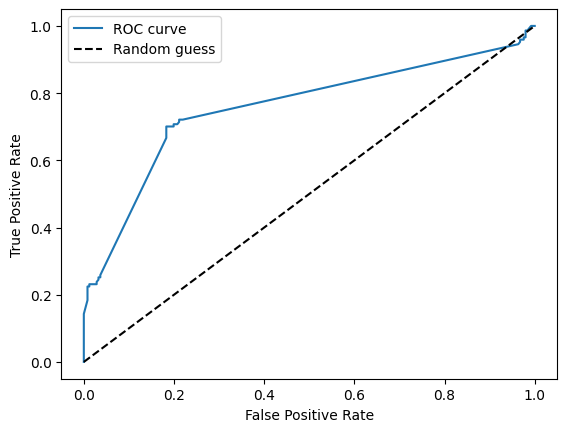

In [48]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# حساب نقاط الـ ROC curve
fpr, tpr, thresholds = roc_curve(y_test, test_probs_class1)

# الرسم
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [49]:
ada_bost = AdaBoostClassifier(n_estimators=200, random_state=44)
ada_bost.fit(x_train[['cabin_maped', 'sex']], y_train)

,estimator,None
,n_estimators,200
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,44


In [50]:
ada_pred_train = ada_bost.predict_proba(x_train[['cabin_maped', 'sex']])
roc_score_train = roc_auc_score(y_train,ada_pred_train[:,1])
print(roc_score_train)

ada_pred_test = ada_bost.predict_proba(x_test[['cabin_maped', 'sex']])

roc_score_test = roc_auc_score(y_test, ada_pred_test[:,1])
print(roc_auc_test)

0.8168301138679374
0.7573143078369559


In [ ]:

ada_bost = AdaBoostClassifier(n_estimators=200, random_state=44)
ada_bost.fit(x_train[['cabin_r_maped', 'sex']], y_train)

ada_pred_train = ada_bost.predict_proba(x_train[['cabin_r_maped', 'sex']])
roc_score_train = roc_auc_score(y_train,ada_pred_train[:,1])
print(roc_score_train)

ada_pred_test = ada_bost.predict_proba(x_test[['cabin_r_maped', 'sex']])

roc_score_test = roc_auc_score(y_test, ada_pred_test[:,1])
print(roc_auc_test)

0.8160426489013228
0.7573143078369559


In [52]:
gbc = GradientBoostingClassifier(n_estimators=200, random_state=44)

gbc.fit(x_train[['cabin_maped', 'sex']], y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [55]:
gbc_pred_train = gbc.predict_proba(x_train[['cabin_maped','sex']])
gbc_roc_train = roc_auc_score(y_train, gbc_pred_train[:,1])
print(gbc_roc_train)

gbc_pred_test = gbc.predict_proba(x_test[['cabin_maped','sex']])
gbc_roc_test = roc_auc_score(y_test, gbc_pred_test[:,1])
print(gbc_roc_test)



0.8572575085916705
0.7538714672861014


In [60]:
gbc = GradientBoostingClassifier(n_estimators=200, random_state=44)

gbc.fit(x_train[['cabin_r_maped', 'sex']], y_train)

gbc_r_predict_train= gbc.predict_proba(x_train[['cabin_r_maped', 'sex']])
gbc_r_roc_train = roc_auc_score(y_train,gbc_r_predict_train[:,1])
print(gbc_r_roc_train)

gbc_r_predict_train= gbc.predict_proba(x_test[['cabin_r_maped', 'sex']])
gbc_r_roc_train = roc_auc_score(y_test,gbc_r_predict_train[:,1])
print(gbc_r_roc_train)


0.816719415917359
0.8015181682429069
